# Reading Other Simulation Codes

Mera began as a RAMSES tool, but its analysis layer is **code-blind** — it works on a generic
uniform/AMR cell list (or particle list), not on RAMSES file formats. So the *same* calls
(`getvar`, `projection`, `subregion`, `timeseries`, `savedata`, …) run on data from several codes:

| Code | grid / particles | what this notebook shows |
|---|---|---|
| **PLUTO** (uniform + Chombo-AMR) | grid | load, getvar |
| **Athena++** | AMR grid + MHD | MHD field, load-time sub-region |
| **FLASH** | AMR grid | a self-gravity potential field |
| **GADGET** (+ GIZMO/AREPO/SWIFT/TNG) | particles + **gas cells** | `getparticles`, gas ρ/T/Z, SPH maps |

It also covers self-gravity, chemistry and radiative-transfer fields, and converting any code to a
Mera file. See the [Multi-code support](https://manuelbehrendt.github.io/Mera.jl/stable/multicode/)
docs for the full reference.

> The test snapshots live under `MERA_TEST_DATA` (download the synthetic/sample data, or point the
> path at your own runs).

In [1]:
using Mera
base = get(ENV, "MERA_TEST_DATA", "/Volumes/FASTStorage/Simulations/Mera-Tests")


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



"/Volumes/FASTStorage/Simulations/Mera-Tests"

## PLUTO (uniform grid)

`getinfo` auto-detects the code from the directory's signature files and prints the same overview a
RAMSES snapshot would; `gethydro` then returns an ordinary `HydroDataType`.

In [2]:
info = getinfo(5, joinpath(base, "PLUTO/pluto_sedov3d"))   # auto-detects PLUTO
gas  = gethydro(info, verbose=false)
maximum(getvar(gas, :rho))                           # the usual analysis, unchanged

[Mera]: 2026-07-29T21:37:41.817



Code: PLUTO
output: 5  time: 0.5 [code units]
grid: 64³ uniform Cartesian, level 6, boxlen = 1.0
variables: (rho, vx, vy, vz, p)
-------------------------------------------------------


4.040484204505616

## Chombo (PLUTO-AMR)

PLUTO's AMR output (the Chombo HDF5 format) loads as a Mera **AMR** object with a `:level` column.

In [3]:
gc = gethydro(getinfo(0, joinpath(base, "CHOMBO/chombo_3d/IsothermalSphere"), verbose=false), verbose=false)
sort(unique(getvar(gc, :level)))                # the refinement levels present

2-element Vector{Float64}:
 6.0
 7.0

## Athena++ (AMR MHD) + a load-time sub-region

Athena++ `.athdf` snapshots carry cell-centred MHD, so `:bx/:by/:bz` and derived `:bmag` work. The
spatial-window arguments load only part of the box (reading only the intersecting MeshBlocks).

In [4]:
ia = getinfo(5, joinpath(base, "ATHENA/athena_blast"))       # a self-built 3-D MHD blast
ga = gethydro(ia, verbose=false)
@show maximum(getvar(ga, :bmag));                    # magnetic field strength

# central 20% box — only the intersecting blocks are read
gsub = gethydro(ia; xrange=[-0.1,0.1], yrange=[-0.1,0.1], zrange=[-0.1,0.1],
                center=[:bc], range_unit=:standard, verbose=false)
length(gsub.data), length(ga.data)                   # sub-region ≪ full snapshot

[Mera]: 2026-07-29T21:37:54.509



Code: Athena++
output: 5  time: 0.50111 [code units]
root grid: 32³ (level 5), MaxLevel 2 ⇒ levels 5:7, boxlen = 2.0
MeshBlocks: 148   variables: (rho, p, vx, vy, vz, bx, by, bz)
-------------------------------------------------------
maximum(getvar(ga, :bmag)) = 1.1211309571451635

(17576, 606208)

## FLASH

FLASH plot files load as AMR hydro/MHD; a self-gravity potential (if present) appears as `:gpot`.

In [5]:
gf = gethydro(getinfo(150, joinpath(base, "FLASH/flash_gassloshing/GasSloshing"), verbose=false), verbose=false)
:gpot in gf.info.variable_list

true

## GADGET / GIZMO / AREPO / SWIFT / IllustrisTNG (particles)

GADGET HDF5 is particle-based, so it loads through `getparticles` into a `PartDataType`. `:family`
is the particle type (0 gas, 1 DM, 2 disk, 3 bulge, 4 stars, 5 BH); `families=` selects a subset.

In [6]:
ig = getinfo(200, joinpath(base, "GADGET/gadget_diskgalaxy/GadgetDiskGalaxy"))
stars = getparticles_gadget(ig; families=[4])        # just the star particles
length(stars.data), msum(stars) > 0

[Mera]: 2026-07-29T21:38:18.870



Code: GADGET
output: 200  time: 0.34483  redshift: 1.9
boxlen = 64000.0
particles: 4334546 gas, 4786616 halo/DM, 2333848 disk, 450921 stars, 1149 bndry/BH  (total 11907080)
-------------------------------------------------------
[Mera]: GADGET particles = 450921, families 4

  (x,y,z,vx,vy,vz,mass,id,family)


(450921, true)

### AREPO / IllustrisTNG — gas-cell physics

For **gas** (`PartType0`) the Voronoi-cell fields are read too, so the full thermodynamic analysis
runs in **physical units** (comoving→physical *a*/*h* is applied automatically for cosmological
runs). Below: a real IllustrisTNG halo cutout.

In [7]:
it  = getinfo(59, joinpath(base, "AREPO/TNGHalo/TNGHalo/halo_59.hdf5"))   # IllustrisTNG (AREPO)
gas = getparticles_gadget(it; families=[0])      # PartType0 gas → :rho,:u,:ne,:metallicity,:sfr,:volume + :T
println("gas cells   : ", length(gas.data))
println("rho [g/cm³] : ", extrema(getvar(gas, :rho, :g_cm3)))
println("T   [K]     : ", extrema(getvar(gas, :T, :K)))
println("metallicity : ", extrema(getvar(gas, :metallicity)))

[Mera]: 2026-07-29T21:38:22.324



Code: AREPO
output: 59  time: 1.0  redshift: 0.0
boxlen = 205000.0
particles: 4006794 gas, 5567314 halo/DM, 533034 stars  (total 10107142)
-------------------------------------------------------
[Mera]: GADGET particles = 4006794, families 0

  (x,y,z,vx,vy,vz,mass,id,family,rho,u,ne,metallicity,sfr,nh,mach,gpot,bx,by,bz,volume)
gas cells   : 4006794
rho [g/cm³] : 

(1.3854807197342735e-30, 1.17827292777639e-22)
T   [K]     : 

(17.965557996942838, 1.2925814640761332e8)
metallicity : (8.100937520794105e-8, 0.04447760060429573)


In [8]:
# the usual reductions run unchanged on AREPO gas, in physical units
n = length(gas.data)
println("median T [K]   : ", sort(getvar(gas, :T, :K))[n ÷ 2])
println("median Z       : ", sort(getvar(gas, :metallicity))[n ÷ 2])
println("gas mass [Msol]: ", msum(gas, :Msol))

median T [K]   : 1.436872560859919e7
median Z       : 

0.001993876649066806
gas mass [Msol]: 4.6930995577059625e13


### Magnetic fields (MHD)

IllustrisTNG is a **magneto**-hydrodynamic run, so its gas carries a `MagneticField`. Mera reads it
into `:bx`/`:by`/`:bz` (physical Gauss; comoving→physical *a⁻²* applied), and `getvar` derives the
usual magnetic quantities — `:bmag` (|B|), `:pmag` (B²/2), plasma `:beta`, Alfvén speed `:v_alfven`,
and the magnetosonic Mach numbers — exactly as for a native RAMSES-MHD run (and they project into
maps like any other field). Below: the **B–ρ relation** (flux freezing, |B| rising with density) and
how the field strength varies across thermal phases, on the real TNG halo gas.

In [9]:
# the magnetic field is read in physical units; getvar derives |B|, β, v_A, … on the gas
nB = length(gas.data)
println("|B|  [μG]       : ", round.(extrema(getvar(gas, :bmag, :muG)), sigdigits=3))
println("median |B| [μG] : ", round(sort(getvar(gas, :bmag, :muG))[nB ÷ 2], sigdigits=3))
println("plasma β        : median ", round(sort(getvar(gas, :beta))[nB ÷ 2], sigdigits=3), "  (≫1 ⇒ thermal-dominated)")
println("v_Alfvén [km/s] : median ", round(sort(getvar(gas, :v_alfven, :km_s))[nB ÷ 2], sigdigits=3))

|B|  [μG]       : (9.88e-7, 357.0)
median |B| [μG] : 0.243
plasma β        : median 

201.0  (≫1 ⇒ thermal-dominated)
v_Alfvén [km/s] : median 43.0


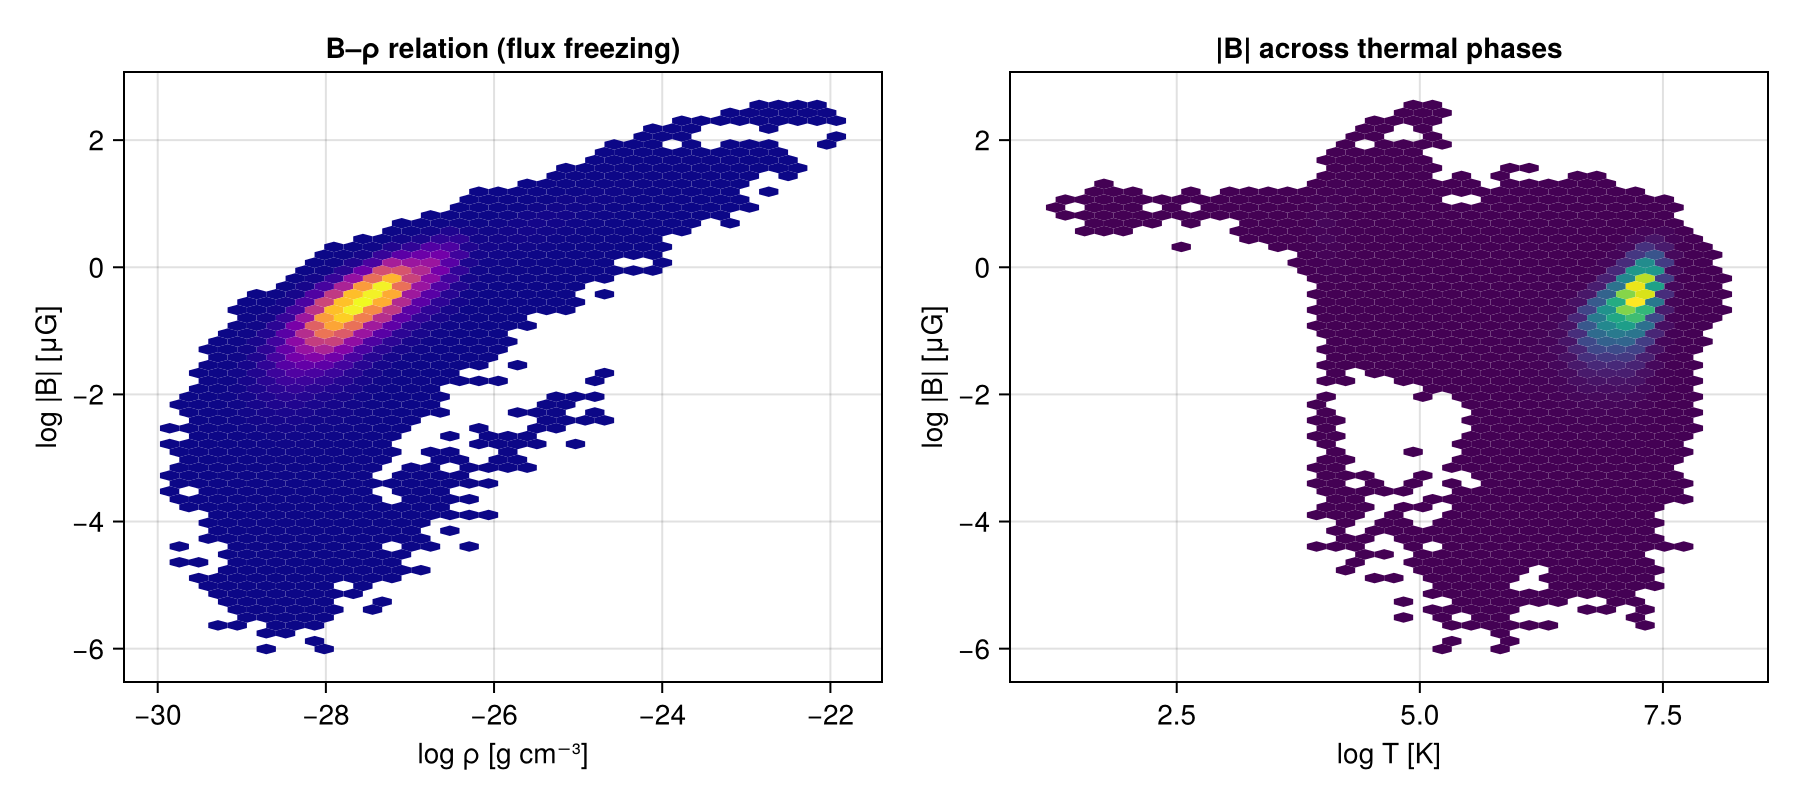

In [10]:
using CairoMakie, Statistics
ρ = getvar(gas, :rho, :g_cm3);  Bμ = getvar(gas, :bmag, :muG);  T = getvar(gas, :T, :K)
ok = (ρ .> 0) .& (Bμ .> 0) .& (T .> 0)
figB = Figure(size=(900, 400))
a1 = Axis(figB[1,1]; title="B–ρ relation (flux freezing)", xlabel="log ρ [g cm⁻³]", ylabel="log |B| [μG]")
hexbin!(a1, log10.(ρ[ok]), log10.(Bμ[ok]); bins=70, colormap=:plasma)
a2 = Axis(figB[1,2]; title="|B| across thermal phases",   xlabel="log T [K]",       ylabel="log |B| [μG]")
hexbin!(a2, log10.(T[ok]), log10.(Bμ[ok]); bins=70, colormap=:viridis)
figB

### Box-filling maps — a full AREPO volume

The TNGHalo above is a halo *cutout*, so its gas is centrally concentrated. For maps that **fill the
frame**, here is `ArepoBullet` — a full AREPO **cluster-merger box** (non-cosmological) whose gas fills
the whole volume. Surface density and mass-weighted temperature (SPH kernel).

[Mera]: 2026-07-29T21:38:41.543



Code: AREPO
output: 150  time: 1.5381  redshift: 0.0
boxlen = 40000.0
particles: 12865831 gas, 13368238 halo/DM, 295531 stars  (total 26529600)
-------------------------------------------------------
[Mera]: GADGET particles = 12865831, families 0

  (x,y,z,vx,vy,vz,mass,id,family,rho,u,gpot,volume)
[Mera]: 2026-07-29T21:38:45.667



center: [0.5, 0.5, 0.5] ==> [19.999 [Mpc] :: 19.999 [Mpc] :: 19.999 [Mpc]]

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]

Effective resolution: 256^2


Pixel size: 156.246 [kpc]
Simulation min.: 19.999 [Mpc]

[Mera]: 2026-07-29T21:39:33.883



center: [0.5, 0.5, 0.5] ==> [19.999 [Mpc] :: 19.999 [Mpc] :: 19.999 [Mpc]]

domain:
xmin::xmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
ymin::ymax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]
zmin::zmax: 0.0 :: 1.0  	==> 0.0 [Mpc] :: 39.999 [Mpc]

Effective resolution: 256^2
Pixel size: 156.246 [kpc]
Simulation min.: 19.999 [Mpc]



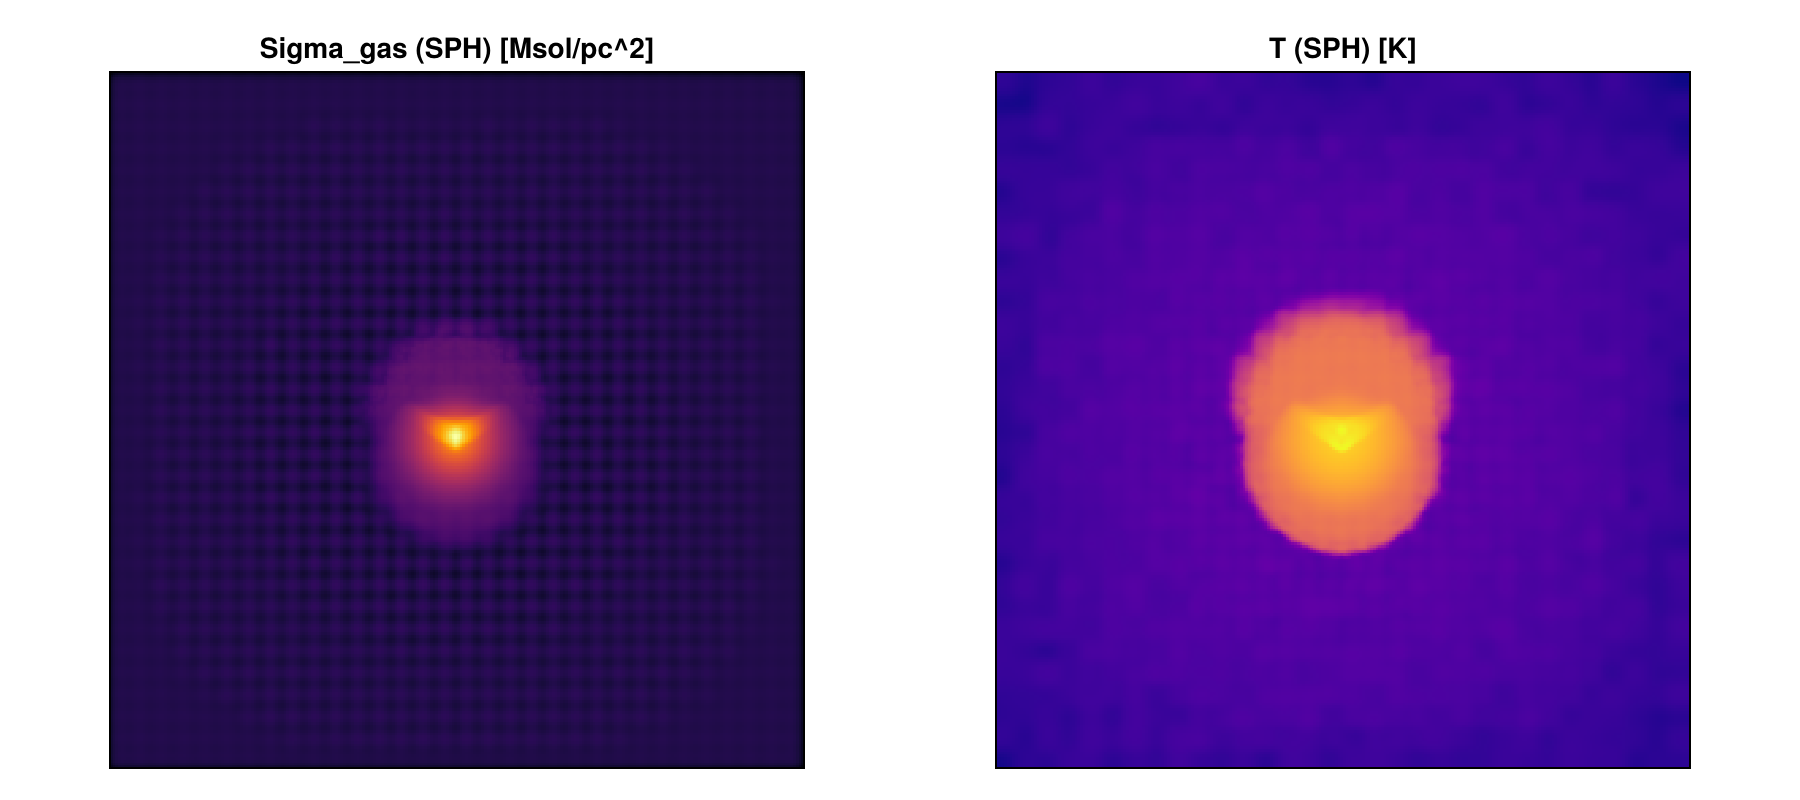

In [11]:
using CairoMakie, Statistics
ib   = getinfo(150, joinpath(base, "AREPO/ArepoBullet/ArepoBullet/snapshot_150.hdf5"))  # AREPO cluster-merger box
bgas = getparticles_gadget(ib; families=[0])
sd = projection(bgas, :sd, :Msol_pc2, res=256, center=[:bc], weighting=:sph)   # fills the frame
Tm = projection(bgas, :T,             res=256, center=[:bc], weighting=:sph)
fig = Figure(size=(900, 400))
a1 = Axis(fig[1,1]; title="Sigma_gas (SPH) [Msol/pc^2]", aspect=DataAspect()); hidedecorations!(a1)
a2 = Axis(fig[1,2]; title="T (SPH) [K]",                  aspect=DataAspect()); hidedecorations!(a2)
heatmap!(a1, log10.(ifelse.(sd.maps[:sd] .> 0, sd.maps[:sd], NaN))'; colormap=:inferno)
heatmap!(a2, log10.(ifelse.(Tm.maps[:T]  .> 0, Tm.maps[:T],  NaN))'; colormap=:plasma)
fig

**SPH vs Voronoi** on the same box-filling run: `weighting=:sph` (smooth, isotropic kernel — the
conserving default) vs `weighting=:voronoi` (nearest-generator — sharp, showing the moving-mesh cells).

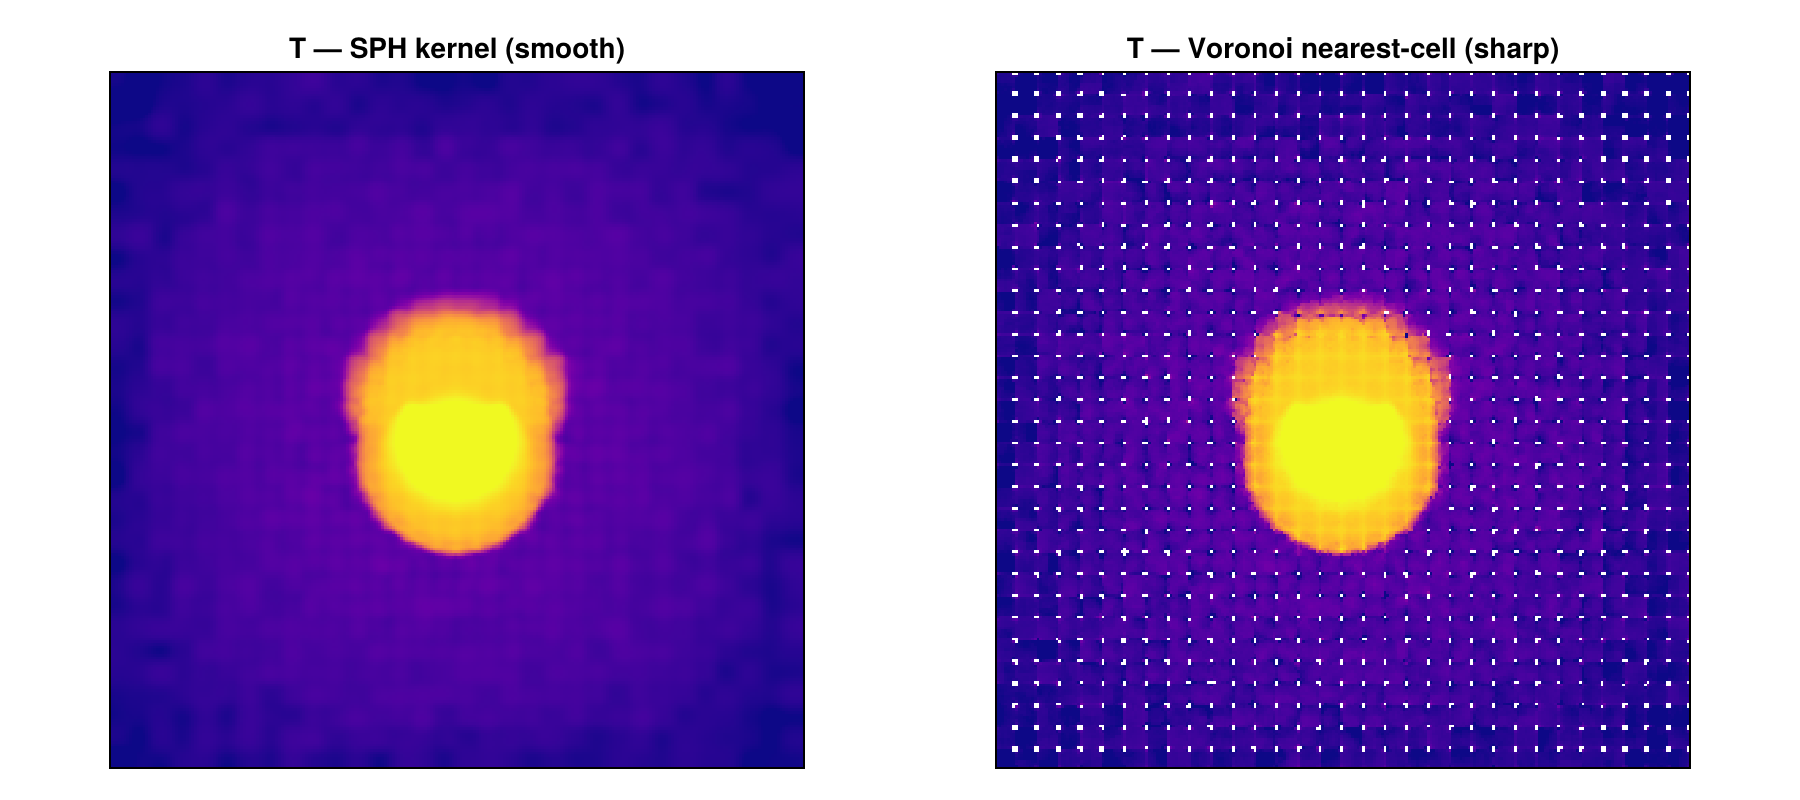

In [12]:
Ts = projection(bgas, :T; res=256, center=[:bc], weighting=:sph,     verbose=false, show_progress=false)
Tv = projection(bgas, :T; res=256, center=[:bc], weighting=:voronoi, verbose=false, show_progress=false)
cr = Tuple(quantile(log10.(filter(>(0), Ts.maps[:T])), [0.02, 0.98]))     # shared colour scale
fig2 = Figure(size=(900, 400))
b1 = Axis(fig2[1,1]; title="T — SPH kernel (smooth)",          aspect=DataAspect()); hidedecorations!(b1)
b2 = Axis(fig2[1,2]; title="T — Voronoi nearest-cell (sharp)", aspect=DataAspect()); hidedecorations!(b2)
heatmap!(b1, log10.(ifelse.(Ts.maps[:T] .> 0, Ts.maps[:T], NaN))'; colormap=:plasma, colorrange=cr)
heatmap!(b2, log10.(ifelse.(Tv.maps[:T] .> 0, Tv.maps[:T], NaN))'; colormap=:plasma, colorrange=cr)
fig2

## Self-gravity, chemistry & radiative transfer

Where a code writes these fields, the reader maps them to **canonical names** — so the same
`getvar` call works across codes: `:gpot` (potential), `:xHI`/`:xH2`/`:xCO` (chemistry species),
`:Np1…:Np8` (radiation photon groups).

In [13]:
sg = gethydro(getinfo(2, joinpath(base, "ATHENA/athena_selfgravity"), verbose=false), verbose=false)
ch = gethydro(getinfo(5, joinpath(base, "ATHENA/athena_chemistry"),  verbose=false), verbose=false)
rt = gethydro(getinfo(5, joinpath(base, "ATHENA/athena_sixray"),     verbose=false), verbose=false)
(gpot = extrema(getvar(sg, :gpot)),
 xH2  = maximum(getvar(ch, :xH2)),                   # H2 fraction (PDR chemistry)
 Np1  = extrema(getvar(rt, :Np1)))                   # UV radiation field, attenuated by shielding

(gpot = (-0.03948165848851204, 0.0446300245821476), xH2 = 0.4545285999774933, Np1 = (2.655466318130493, 7.641556739807129))

## Convert any code to a Mera file

`savedata`/`loaddata` round-trips **any** loaded object to Mera's portable JLD2 format — so a saved
series even feeds `timeseries(…; mera_files=true)`.

In [14]:
tmp = mktempdir()
savedata(ga, tmp; fmode=:write, verbose=false)
g2 = loaddata(5, tmp, :hydro; verbose=false)
length(g2.data) == length(ga.data) && getvar(g2, :rho) == getvar(ga, :rho)

true

---
Every call above is identical to what you'd run on a RAMSES snapshot — that is the whole point of
the code-blind analysis layer. For per-code details (units, variable mapping, coordinate
conventions, reference readers) see the
[Other Simulation Codes](https://manuelbehrendt.github.io/Mera.jl/stable/multicode/) docs.